# Advanced Insights
## Superstore Sales EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.options.display.float_format = '{:,.2f}'.format

sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/Sample - Superstore.csv', encoding='latin-1')
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days

In [2]:
pivot_profit = df.pivot_table(
    values='profit',
    index='region',
    columns='category',
    aggfunc='sum'
)
pivot_profit

category,Furniture,Office Supplies,Technology
region,,,
Central,"-2,871.05","8,879.98","33,697.43"
East,"3,046.17","41,014.58","47,462.04"
South,"6,771.21","19,986.39","19,991.83"
West,"11,504.95","52,609.85","44,303.65"


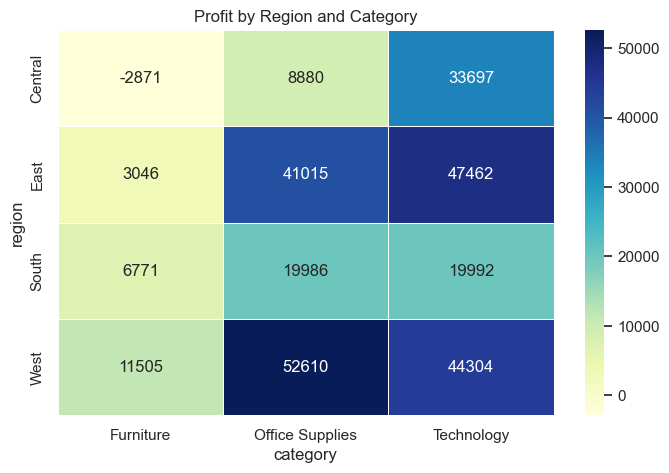

In [10]:
plt.figure(figsize=(8,5))
sns.heatmap(pivot_profit, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5)
plt.title('Profit by Region and Category')
plt.savefig('../visuals/profit_by_region_and_category.png', dpi=150, bbox_inches='tight')
plt.show()

Central + Furniture = -2871 — the only loss-making cell in the entire matrix. Central is selling Furniture at a loss.

West + Office Supplies = 52,610 — highest profit cell. West is the powerhouse region.

East + Technology = 47,462 — second strongest performer.

Furniture is pale/yellow across all regions meaning consistently weak margins everywhere, but Central is the only one actually losing money.

In [4]:
#Top 10 profitable products
top_products = df.groupby('product_name')['profit'].sum().sort_values(ascending=False).head(10).reset_index()
top_products

,product_name,profit
0,Canon imageCLASS 2200 Advanced Copier,"25,199.93"
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,"7,753.04"
2,Hewlett Packard LaserJet 3310 Copier,"6,983.88"
3,Canon PC1060 Personal Laser Copier,"4,570.93"
4,HP Designjet T520 Inkjet Large Format Printer ...,"4,094.98"
5,Ativa V4110MDD Micro-Cut Shredder,"3,772.95"
6,"3D Systems Cube Printer, 2nd Generation, Magenta","3,717.97"
7,Plantronics Savi W720 Multi-Device Wireless He...,"3,696.28"
8,Ibico EPK-21 Electric Binding System,"3,345.28"
9,Zebra ZM400 Thermal Label Printer,"3,343.54"


C:\Users\Mohammed Yousuf\AppData\Local\Temp\ipykernel_30608\3530707420.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, y='product_name', x='profit', palette='viridis')


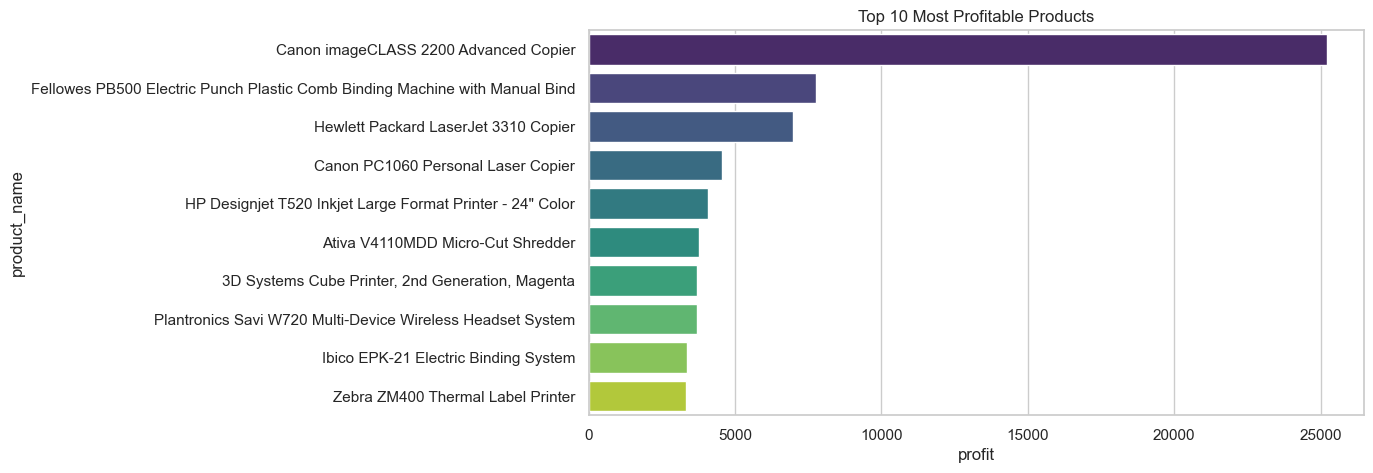

In [11]:
plt.figure(figsize=(10,5))
sns.barplot(data=top_products, y='product_name', x='profit', palette='viridis')
plt.title('Top 10 Most Profitable Products')
plt.savefig('../visuals/top_10_profitable_products.png', dpi=150, bbox_inches='tight')
plt.show()

Canon imageCLASS 2200 Advanced Copier dominates with ~25,000 profit — more than double the second product (Fellowes PB500 at ~7,500). The top 10 is almost entirely printing and office equipment. These are high-ticket, low-discount products which explains their strong margins.